# K-Nearest Neighbors: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **K-Nearest Neighbors** in Python.

### Concept Overview
Classifies objects by comparing distances to their closest labeled neighbors in the feature space.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2} \quad \text{(Euclidean Distance)}
$$

### Real-World Analogy
**Analogy:** 'Birds of a feather flock together.' You behave similarly to the 5 closest friends you interact with.

### Worked Example
**Worked Example:** Classifying a new cell as malignant. We calculate Euclidean distances to all known cells. If 5 nearest neighbors contains 4 malignant cells and 1 benign cell, we classify the cell as malignant (80% majority vote).

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of tumor coordinates
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=400, n_features=2, n_informative=2,
                                  n_redundant=0, n_classes=2, n_clusters_per_class=1,
                                  class_sep=1.5, random_state=42)
df = pd.DataFrame({
    'Size': np.round(X_raw[:, 0] * 3 + 6, 2),
    'Texture': np.round(X_raw[:, 1] * 5 + 20, 2),
    'Malignant': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (400, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Size       400 non-null    float64
 1   Texture    400 non-null    float64
 2   Malignant  400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
             Size     Texture   Malignant
count  400.000000  400.000000  400.000000
mean    10.418800   20.074600    0.500000
std      2.040151    9.052482    0.500626
min      2.030000   -0.290000    0.000000
25%      9.087500   12.570000    0.000000
50%     10.410000   20.795000    0.500000
75%     11.702500   27.500000    1.000000
max     16.180000   39.230000    1.000000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Size         0
Texture      0
Malignant    0
dtype: int64
Duplicate count: 1


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

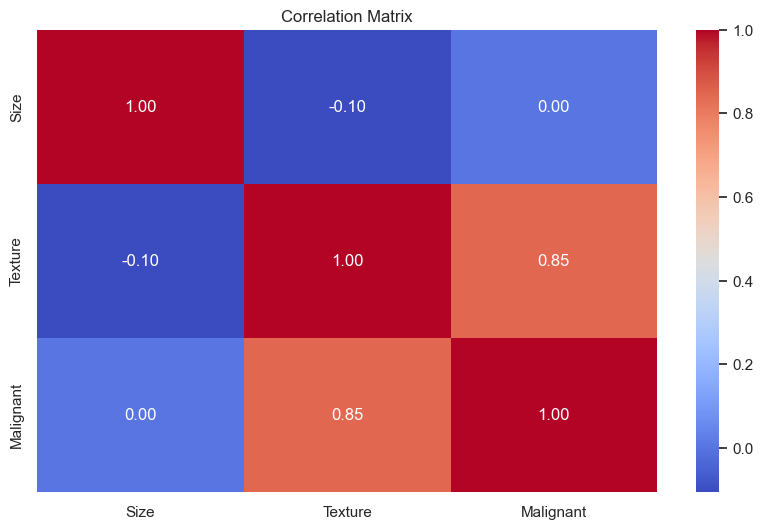

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling applied successfully.')

Scaling applied successfully.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (280, 2), Test size: (120, 2)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print("KNN model fitted.")

KNN model fitted.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))

Accuracy: 0.95
F1 Score: 0.9464285714285714
Confusion Matrix:
 [[61  5]
 [ 1 53]]


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

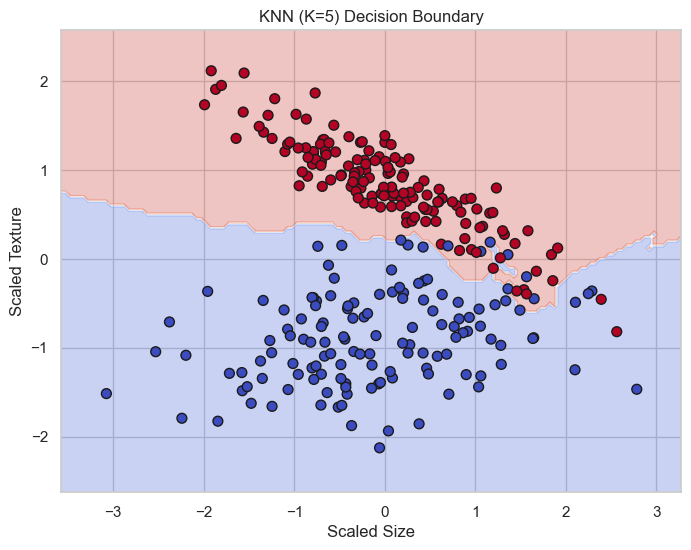

In [10]:
# Decision Boundary Plotting for KNN
h = 0.05
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=50)
plt.title("KNN (K=5) Decision Boundary")
plt.xlabel("Scaled Size")
plt.ylabel("Scaled Texture")
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: Why is KNN called a lazy learner?**

*A: Because it has no explicit training phase. It simply stores the training dataset and performs all computations during inference.*

**Q2: What is the impact of K parameter choice?**

*A: Small K (e.g. K=1) leads to high variance and overfitting (sensitive to noise). Large K leads to high bias and underfitting (smooths boundaries).*

**Q3: Why is feature scaling critical for KNN?**

*A: KNN calculates distance metrics. Features with larger ranges (e.g. income) dominate features with smaller ranges (e.g. age) if left unscaled.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: How do you break ties when using KNN for binary classification?**

*A: Use an odd value of K (e.g., K = 3, 5, 7) to avoid equal voting outcomes.*

**Q2: What is the default distance metric in scikit-learn's KNN?**

*A: Minkowski distance with p=2, which is equivalent to Euclidean distance.*

**Q3: Name one disadvantage of KNN.**

*A: It is computationally expensive and slow during inference on large datasets because it must scan all training points.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.